# Do anglicism rise across time in the french language in a political and european context ? A diachronic study on European Parlament's data

**Author** : Naïs Noël

**Date** : May 2026

## Abstract :

This study investigates whether anglicisms in French have increased over time in a European institutional context. Using a corpus of 6,205 parliamentary speeches from the European Parliament (1996–2009), I developed an automated detection pipeline based on Wiktionnaire to classify words into four categories. Four linear regressions were computed. Results show that real anglicisms, words of English origin, and complete anglicisms all increase significantly over time, while loanwords show no significant trend. These findings suggest that, despite the formal nature of parliamentary speech, French in European institutional contexts is not immune to anglicisation.

## Introduction : 
Since the intensification of globalization worldwide—economically, culturally, and politically—certain languages have tended to borrow or adapt words from other languages, often considered more “trendy” or more diplomatic. But, for some strange reason, only a tiny fraction of linguistic articles devoted to the French language have examined these trends (John Humbley, 2010)[1]. 
Of course, given the marked conservatism of the famous “Académie française,” the reason seems obvious. But is the French language as rigid as many people imagine? 
Parliamentary speeches, though formal by nature, take place in a multilingual European context where English plays a central role as a working language, making them a particularly relevant corpus for studying anglicism penetration. 
In this study, I will focus my analysis solely on morphological Anglicisms—both integrated and complete—and loanwords.
Since Wiktionnaire is an excellent dictionary for anglicism tags (John Humbley, 2023)[2], I have chosen to use it in this study.


**_Do anglicisms rise across time in the french language in a political and european context ?_**

   
*Prediction 1: The use of real anglicisms rises with the years*    

*Prediction 2: The use of words of english origins rises with the years*   

*Prediction 3: The use of loanwords rises with years*

*Prediction 4: The use of complete / integrated anglicisms rises with the years*



## 1. Library import 

In [6]:
# Computing libraries
import nltk
from nltk.corpus import stopwords
import glob
import os
import json
import re
import csv
import pandas as pd
import numpy as np
import networkx as nx
from collections import Counter
from tqdm import tqdm
import ast  
import requests
import time
import statsmodels.formula.api as smf
import time
from tqdm import tqdm
import requests
from bs4 import BeautifulSoup
from scipy.stats import linregress
from pathlib import Path

# Graphical libraries
import seaborn as sns
import matplotlib.pyplot as plt

nltk.download('stopwords')
stops = set(stopwords.words('french'))


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\naisn\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


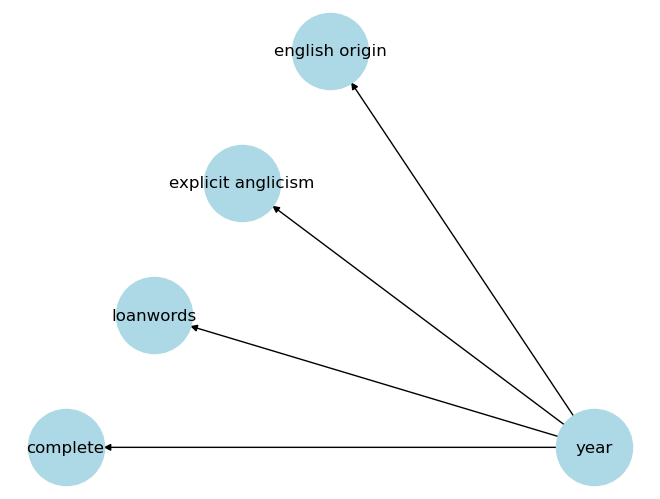

In [2]:
# Create a directed graph
G = nx.DiGraph()

# Add nodes
nodes = ['complete', 'loanwords', 'explicit anglicism', 'english origin']
G.add_nodes_from(nodes)

# Add edges (directed connections)
edges = [('year','complete'), ('year','loanwords'), ('year','explicit anglicism'), ('year','english origin')]
G.add_edges_from(edges)

# Draw the graph
pos = nx.planar_layout(G)
nx.draw(G, pos, with_labels = True, node_size = 3000, node_color ='lightblue', arrows = True)
plt.show()

## 2. Data import 

To test these hypotheses, I used the fitth version of a corpus of European Parliament speeches titled “European Parliament Proceedings Parallel Corpus”, https://www.statmt.org/europarl/archives.html#v5. These speeches cover the period from 1997 to 2009 (N = 6,205). 

I included only the French and English translations of all speeches that mentioned both the speaker’s name and the language used, in this case French.

### 2.1 French corpus

In [ ]:
path_discourse_french = Path("fr-en") / "fr"

In [8]:
def read_txt(path_discourse):
    with open(path_discourse, "r", encoding="utf-8") as file:
        lines = file.read()
        
    return lines

In [13]:
read_txt(path_discourse_french / "ep-00-01-17.txt")

'<CHAPTER ID=1>\nReprise de la session\n<SPEAKER ID=1 NAME="La Présidente">\nJe déclare reprise la session du Parlement européen qui avait été interrompue le vendredi 17 décembre dernier et je vous renouvelle tous mes vux en espérant que vous avez passé de bonnes vacances.\n<P>\nComme vous avez pu le constater, le grand "bogue de l\'an 2000" ne s\'est pas produit. En revanche, les citoyens d\'un certain nombre de nos pays ont été victimes de catastrophes naturelles qui ont vraiment été terribles.\nVous avez souhaité un débat à ce sujet dans les prochains jours, au cours de cette période de session.\nEn attendant, je souhaiterais, comme un certain nombre de collègues me l\'ont demandé, que nous observions une minute de silence pour toutes les victimes, des tempêtes notamment, dans les différents pays de l\'Union européenne qui ont été touchés.\nJe vous invite à vous lever pour cette minute de silence.\n<P>\n(Le Parlement, debout, observe une minute de silence)\n<P>\n<SPEAKER ID=2 LANGUA

In [225]:
for filepath in glob.glob(os.path.join(path_discourse_french, "*.txt")):
    filename = os.path.basename(filepath)  # file name only
    print(filename)  # verify

ep-00-01-17.txt
ep-00-01-18.txt
ep-00-01-19.txt
ep-00-01-21.txt
ep-00-02-02.txt
ep-00-02-03.txt
ep-00-02-14.txt
ep-00-02-15.txt
ep-00-02-16.txt
ep-00-02-17.txt
ep-00-02-18.txt
ep-00-03-01.txt
ep-00-03-02.txt
ep-00-03-13.txt
ep-00-03-14.txt
ep-00-03-15.txt
ep-00-03-16.txt
ep-00-03-17.txt
ep-00-03-29.txt
ep-00-03-30.txt
ep-00-04-10.txt
ep-00-04-11.txt
ep-00-04-12.txt
ep-00-04-13.txt
ep-00-04-14.txt
ep-00-05-03.txt
ep-00-05-04.txt
ep-00-05-15.txt
ep-00-05-16.txt
ep-00-05-17.txt
ep-00-05-18.txt
ep-00-05-19.txt
ep-00-06-13.txt
ep-00-06-14.txt
ep-00-06-15.txt
ep-00-06-16.txt
ep-00-07-03.txt
ep-00-07-04.txt
ep-00-07-05.txt
ep-00-07-06.txt
ep-00-07-07.txt
ep-00-09-04.txt
ep-00-09-05.txt
ep-00-09-06.txt
ep-00-09-07.txt
ep-00-09-08.txt
ep-00-09-20.txt
ep-00-09-21.txt
ep-00-10-02.txt
ep-00-10-03.txt
ep-00-10-04.txt
ep-00-10-05.txt
ep-00-10-06.txt
ep-00-10-23.txt
ep-00-10-24.txt
ep-00-10-25.txt
ep-00-10-26.txt
ep-00-10-27.txt
ep-00-11-13.txt
ep-00-11-14.txt
ep-00-11-15.txt
ep-00-11-16.txt
ep-00-11

In [226]:
def date_from_filename(filename):
    match = re.search(r'ep-(\d{2})-(\d{2})-(\d{2})', filename)
    if match:
        year, month, day = match.groups()
        if year < "90":
            return f"20{year}", month, day  # ep-00 → 2000
        else:
            return f"19{year}", month, day  # ep-97 → 1997
    return None, None, None

In [227]:
date_from_filename("ep-99-11-03.txt")

('1999', '11', '03')

In [228]:
with open("parlement_discourse_french.csv", "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["filename", "year", "month", "day", "data"])

    for filepath in glob.glob(path_discourse_french + "/*.txt"):
        filename = os.path.basename(filepath)
        year = date_from_filename(filename)[0]
        month = date_from_filename(filename)[1]
        day = date_from_filename(filename)[2]
        data = read_txt(filepath)  
        
        writer.writerow([filename, year, month, day, data])

In [229]:
dataset_parlament_french = pd.read_csv("parlement_discourse_french.csv")

In [230]:
dataset_parlament_french

,filename,year,month,day,data
0,ep-00-01-17.txt,2000,1,17,<CHAPTER ID=1>\nReprise de la session\n<SPEAKE...
1,ep-00-01-18.txt,2000,1,18,<CHAPTER ID=1>\nAdoption du procès-verbal de l...
2,ep-00-01-19.txt,2000,1,19,<CHAPTER ID=5>\nProcessus de paix au Moyen-Ori...
3,ep-00-01-21.txt,2000,1,21,<CHAPTER ID=1>\nAdoption du procès-verbal de l...
4,ep-00-02-02.txt,2000,2,2,<CHAPTER ID=1>\nReprise de la session\n<SPEAKE...
...,...,...,...,...,...
6198,ep-99-12-13.txt,1999,12,13,<CHAPTER ID=1>\nReprise de la session\n<SPEAKE...
6199,ep-99-12-14.txt,1999,12,14,<CHAPTER ID=1>\nReprise de la séance\n<SPEAKER...
6200,ep-99-12-15.txt,1999,12,15,<CHAPTER ID=1>\nCommunication du Président\n<S...
6201,ep-99-12-16.txt,1999,12,16,<CHAPTER ID=1>\nAdoption du procès-verbal de l...


### 2.2 English corpus

In [14]:
path_discourse_english = path_discourse_french = Path("fr-en") / "en"

In [15]:
read_txt(path_discourse_english / "ep-00-01-17.txt")

'<CHAPTER ID=1>\nResumption of the session\n<SPEAKER ID=1 NAME="President">\nI declare resumed the session of the European Parliament adjourned on Friday 17 December 1999, and I would like once again to wish you a happy new year in the hope that you enjoyed a pleasant festive period.\n<P>\nAlthough, as you will have seen, the dreaded \'millennium bug\' failed to materialise, still the people in a number of countries suffered a series of natural disasters that truly were dreadful.\nYou have requested a debate on this subject in the course of the next few days, during this part-session.\nIn the meantime, I should like to observe a minute\' s silence, as a number of Members have requested, on behalf of all the victims concerned, particularly those of the terrible storms, in the various countries of the European Union.\nPlease rise, then, for this minute\' s silence.\n<P>\n(The House rose and observed a minute\' s silence)\n<P>\n<SPEAKER ID=2 NAME="Evans, Robert J">\nMadam President, on a 

In [16]:
for filepath in glob.glob(os.path.join(path_discourse_english, "*.txt")):
    filename = os.path.basename(filepath)  # file name only
    print(filename)  # verify

ep-00-01-17.txt
ep-00-01-18.txt
ep-00-01-19.txt
ep-00-01-21.txt
ep-00-02-02.txt
ep-00-02-03.txt
ep-00-02-14.txt
ep-00-02-15.txt
ep-00-02-16.txt
ep-00-02-17.txt
ep-00-02-18.txt
ep-00-03-01.txt
ep-00-03-02.txt
ep-00-03-13.txt
ep-00-03-14.txt
ep-00-03-15.txt
ep-00-03-16.txt
ep-00-03-17.txt
ep-00-03-29.txt
ep-00-03-30.txt
ep-00-04-10.txt
ep-00-04-11.txt
ep-00-04-12.txt
ep-00-04-13.txt
ep-00-04-14.txt
ep-00-05-03.txt
ep-00-05-04.txt
ep-00-05-15.txt
ep-00-05-16.txt
ep-00-05-17.txt
ep-00-05-18.txt
ep-00-05-19.txt
ep-00-06-13.txt
ep-00-06-14.txt
ep-00-06-15.txt
ep-00-06-16.txt
ep-00-07-03.txt
ep-00-07-04.txt
ep-00-07-05.txt
ep-00-07-06.txt
ep-00-07-07.txt
ep-00-09-04.txt
ep-00-09-05.txt
ep-00-09-06.txt
ep-00-09-07.txt
ep-00-09-08.txt
ep-00-09-20.txt
ep-00-09-21.txt
ep-00-10-02.txt
ep-00-10-03.txt
ep-00-10-04.txt
ep-00-10-05.txt
ep-00-10-06.txt
ep-00-10-23.txt
ep-00-10-24.txt
ep-00-10-25.txt
ep-00-10-26.txt
ep-00-10-27.txt
ep-00-11-13.txt
ep-00-11-14.txt
ep-00-11-15.txt
ep-00-11-16.txt
ep-00-11

In [234]:
with open("parlement_discourse_english.csv", "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["filename", "year", "month", "day", "data"])

    for filepath in glob.glob(path_discourse_english + "/*.txt"):
        filename = os.path.basename(filepath)
        year = date_from_filename(filename)[0]
        month = date_from_filename(filename)[1]
        day = date_from_filename(filename)[2]
        data = read_txt(filepath)  
        
        writer.writerow([filename, year, month, day, data])

In [235]:
dataset_parlament_english = pd.read_csv("parlement_discourse_english.csv")

In [236]:
dataset_parlament_english

,filename,year,month,day,data
0,ep-00-01-17.txt,2000,1,17,<CHAPTER ID=1>\nResumption of the session\n<SP...
1,ep-00-01-18.txt,2000,1,18,<CHAPTER ID=1>\nAdoption of the Minutes of the...
2,ep-00-01-19.txt,2000,1,19,<CHAPTER ID=5>\nMiddle East peace process (con...
3,ep-00-01-21.txt,2000,1,21,<CHAPTER ID=1>\nAdoption of the Minutes of the...
4,ep-00-02-02.txt,2000,2,2,<CHAPTER ID=1>\nResumption of the session\n<SP...
...,...,...,...,...,...
6198,ep-99-12-13.txt,1999,12,13,<CHAPTER ID=1>\nResumption of the session\n<SP...
6199,ep-99-12-14.txt,1999,12,14,<CHAPTER ID=1>\nResumption of the sitting\n<SP...
6200,ep-99-12-15.txt,1999,12,15,<CHAPTER ID=1>\nStatement by the President\n<S...
6201,ep-99-12-16.txt,1999,12,16,<CHAPTER ID=1>\nAdoption of the Minutes of the...


## 3. Data manipulation

### 3.1 Functions tests :

I then created several functions to access information about the number of words found in the speech of native French speakers, which, according to Wiktionnaire, are classified into one of the following categories: Anglicisms, calques (Anglicisms), words of English origin, and loanwords. 

To identify candidate words potentially linked to English, I first used a batch function **search_candidates_batch** based on raw wikitext patterns, which allowed me to build an initial cache of around 928 words flagged as having some connection to English. Although this first function produced some false positives, it served as a useful pre-filter, significantly reducing the number of words to re-verify. I then applied a more precise function **classify_word_wiktio** based on parsed HTML from Wiktionnaire, which re-classified each candidate word into one of four categories: real anglicism, english origin, loanword, or complete/integrated anglicism

To avoid stopwords, plurals, capitalization issues, and a few false positives, the words that were candidates were filtered out using the **prepare_candidates function**

In [237]:
test_text = "Ce week-end, j'ai décidé de tester mon nouveau smartphone en regardant des vidéos de streaming sur mon canapé. J'avais téléchargé une application de fitness pour suivre mon jogging matinal, mais le coach virtuel me spammait de notifications. J'ai donc mis mon téléphone en mode offline et branché mon laptop pour bosser sur un projet de marketing digital. Après un brainstorming intense, j'ai envoyé un email à mon manager pour lui partager mon feedback. Le soir, j'ai commandé un burger via une app de fast-food et regardé un documentaire sur le business model des startups californiennes. Avant de dormir, j'ai scrollé sur les réseaux sociaux, liké quelques posts et rejoint un live sur les tendances du e-commerce."

In [238]:
def compte_mots(discourse):
    dico_A = {}
    mots = re.findall(r'\b[a-zA-ZÀ-ÿ]+(?:-[a-zA-ZÀ-ÿ]+)*\b', discourse)
    for mot in mots:
        if mot not in dico_A:
            dico_A[mot] = 1
        else:
            dico_A[mot] += 1
    return dico_A

In [239]:
compte_mots(test_text)

{'Ce': 1,
 'week-end': 1,
 'j': 4,
 'ai': 5,
 'décidé': 1,
 'de': 7,
 'tester': 1,
 'mon': 7,
 'nouveau': 1,
 'smartphone': 1,
 'en': 2,
 'regardant': 1,
 'des': 2,
 'vidéos': 1,
 'streaming': 1,
 'sur': 5,
 'canapé': 1,
 'J': 2,
 'avais': 1,
 'téléchargé': 1,
 'une': 2,
 'application': 1,
 'fitness': 1,
 'pour': 3,
 'suivre': 1,
 'jogging': 1,
 'matinal': 1,
 'mais': 1,
 'le': 2,
 'coach': 1,
 'virtuel': 1,
 'me': 1,
 'spammait': 1,
 'notifications': 1,
 'donc': 1,
 'mis': 1,
 'téléphone': 1,
 'mode': 1,
 'offline': 1,
 'et': 3,
 'branché': 1,
 'laptop': 1,
 'bosser': 1,
 'un': 6,
 'projet': 1,
 'marketing': 1,
 'digital': 1,
 'Après': 1,
 'brainstorming': 1,
 'intense': 1,
 'envoyé': 1,
 'email': 1,
 'à': 1,
 'manager': 1,
 'lui': 1,
 'partager': 1,
 'feedback': 1,
 'Le': 1,
 'soir': 1,
 'commandé': 1,
 'burger': 1,
 'via': 1,
 'app': 1,
 'fast-food': 1,
 'regardé': 1,
 'documentaire': 1,
 'business': 1,
 'model': 1,
 'startups': 1,
 'californiennes': 1,
 'Avant': 1,
 'dormir': 1,
 '

In [ ]:
def search_candidates_batch(liste_mots, batch_size=20, pause=1.0):
    results = {}
    
    for i in tqdm(range(0, len(liste_mots), batch_size)):
        batch = liste_mots[i:i+batch_size]
        titles = "|".join(batch)
        url = "https://fr.wiktionary.org/w/api.php"
        params = {
            "action": "query",
            "titles": titles,
            "prop": "revisions",
            "rvprop": "content",
            "format": "json"
        }
        try:
            r = requests.get(url, params=params, headers=headers)
            data = r.json()
            pages = data["query"]["pages"]
            
            for page in pages.values():
                mot = page.get("title", "")
                wikitext = ""
                if "revisions" in page:
                    wikitext = page["revisions"][0].get("*", "") or \
                               page["revisions"][0].get("slots", {}).get("main", {}).get("*", "")
                
                if "Emprunt de l\u2019{{étyl|en|fr" in wikitext:
                    results[mot] = "borrowing"
                elif "{{emprunt|en|fr" in wikitext:
                    results[mot] = "borrowing"
                elif "{{anglicisme|fr" in wikitext:
                    results[mot] = "anglicism"
                elif "{{étyl|en|fr" in wikitext:
                    results[mot] = "etymology"
                elif "Emprunt de l\u2019{{étyl|en" in wikitext:
                    results[mot] = "borrowing"
                elif "{{étyl|en" in wikitext:
                    results[mot] = "etymology"
                    
        except Exception as e:
            print(f"Erreur batch {i}: {e}")
        
        time.sleep(pause)
    
    return results

In [ ]:
session = requests.Session()

session.headers.update({
    "User-Agent": (
        "Mozilla/5.0"
    )
})
def classify_word_wiktio(word, retries=3):

    url = "https://fr.wiktionary.org/w/api.php"

    params = {
        "action": "parse",
        "page": word,
        "prop": "text",
        "format": "json"
    }
    
    
    
    for attempt in range(retries):

        try:

            r = session.get(url,params=params,timeout=15)

            content_type = r.headers.get("Content-Type","")

            if "json" not in content_type:

                time.sleep(2)
                continue

            data = r.json()

            if "parse" not in data:
                return None

            html = data["parse"]["text"]["*"]

            soup = BeautifulSoup(html,"lxml")

            full_text = soup.get_text(" ",strip=True).lower()

            labels = []

            
            # explicit anglicism detection
            

            if "anglicisme" in full_text:

                labels.append("explicit_anglicism_in_one_sense")

            
            # english origin patterns
            loanword_patterns = ["emprunté à l\u2019anglais",
                "emprunté à l'anglais",
                "emprunt à l\u2019anglais",
                "emprunt à l'anglais",
                "emprunt de l\u2019anglais",
                "emprunt de l'anglais"
            ]
            
            for pattern in loanword_patterns:

                if pattern in full_text:

                    labels.append("loanword")

                    break
            
            calque_patterns = ["calque de l\u2019anglais",
                "calque de l'anglais"
            ]
            
            for pattern in calque_patterns:

                if pattern in full_text:

                    labels.append("calque")

                    break
                    
            
            english_patterns = [
                "de l\u2019anglais",
                "de l'anglais",
                "Initiales de l\u2019anglais",
                "Initiales de l'anglais"
            ]

            for pattern in english_patterns:

                if pattern in full_text:

                    labels.append("english_origin")

                    break
            

            if labels:
                return labels

            return None

        except Exception as e:

            print(
                f"Attempt {attempt+1} "
                f"Failed for {word}: {e}"
            )

            time.sleep(2)

    return None

In [242]:
classify_word_wiktio("réaliser")

['explicit_anglicism_in_one_sense', 'calque', 'english_origin']

In [ ]:
#You have to run it multiple times to get a better classification due to the instability of the Wiktionary API and the possibility of temporary errors.
CACHE_FILE = "cache_anglicismes_test2.json"
def load_cache():
    if os.path.exists(CACHE_FILE):
        with open(CACHE_FILE, "r", encoding="utf-8") as f:
            return json.load(f)
    return {}

def save_cache(cache):
    with open(CACHE_FILE, "w", encoding="utf-8") as f:
        json.dump(cache, f, ensure_ascii=False, indent=2)

def search_anglicism_test(liste_mots, pause=1):
    cache = load_cache()
    results = {}
    to_fetch = [mot for mot in liste_mots if cache.get(mot) is None]

    print(f"{len(liste_mots) - len(to_fetch)} in cache, {len(to_fetch)} to request")

    for mot in tqdm(to_fetch):
        result = classify_word_wiktio(mot)
        results[mot] = result

        if result is not None:
            cache[mot] = result
            save_cache(cache)

        time.sleep(pause)

    for mot in liste_mots:
        results[mot] = cache.get(mot)

    return results

In [244]:
false_positivs = {"via", "maximum", "minimum", "forum"} #latin words that are not anglicisms but could be misidentified as such

def prepare_candidates(dico_mots, freq_min=5):
    candidates = []
    for word, freq in dico_mots.items():
        
        if word.isupper():
            continue

        if word in false_positivs:
            continue
        
        if word.lower() in stops:
            continue
        if freq < freq_min:
            continue
    
        if len(word) < 3:
            continue
        
        # lematisation of plural in anglicism detection
        if word.endswith("s") and len(word) > 5 and not word.endswith("ss"):
            word = word[:-1]

        candidates.append(word)
    return candidates

In [245]:
candidate_test = prepare_candidates(compte_mots(test_text), freq_min=1)
candidate_test

['week-end',
 'décidé',
 'tester',
 'nouveau',
 'smartphone',
 'regardant',
 'vidéo',
 'streaming',
 'canapé',
 'téléchargé',
 'application',
 'fitness',
 'suivre',
 'jogging',
 'matinal',
 'coach',
 'virtuel',
 'spammait',
 'notification',
 'donc',
 'mis',
 'téléphone',
 'mode',
 'offline',
 'branché',
 'laptop',
 'bosser',
 'projet',
 'marketing',
 'digital',
 'Après',
 'brainstorming',
 'intense',
 'envoyé',
 'email',
 'manager',
 'partager',
 'feedback',
 'soir',
 'commandé',
 'burger',
 'app',
 'fast-food',
 'regardé',
 'documentaire',
 'business',
 'model',
 'startup',
 'californienne',
 'Avant',
 'dormir',
 'scrollé',
 'réseaux',
 'sociaux',
 'liké',
 'quelque',
 'posts',
 'rejoint',
 'live',
 'tendance',
 'e-commerce']

In [246]:
search_anglicism_test(candidate_test, pause=0.5)

0 in cache, 61 to request


100%|██████████| 61/61 [03:45<00:00,  3.69s/it]


{'week-end': ['explicit_anglicism_in_one_sense', 'loanword'],
 'décidé': None,
 'tester': ['english_origin'],
 'nouveau': None,
 'smartphone': ['explicit_anglicism_in_one_sense',
  'loanword',
  'english_origin'],
 'regardant': None,
 'vidéo': ['loanword', 'english_origin'],
 'streaming': ['explicit_anglicism_in_one_sense', 'english_origin'],
 'canapé': None,
 'téléchargé': None,
 'application': None,
 'fitness': None,
 'suivre': None,
 'jogging': None,
 'matinal': None,
 'coach': ['explicit_anglicism_in_one_sense', 'english_origin'],
 'virtuel': None,
 'spammait': None,
 'notification': None,
 'donc': None,
 'mis': None,
 'téléphone': None,
 'mode': None,
 'offline': None,
 'branché': None,
 'laptop': None,
 'bosser': None,
 'projet': None,
 'marketing': None,
 'digital': None,
 'Après': None,
 'brainstorming': ['explicit_anglicism_in_one_sense', 'english_origin'],
 'intense': None,
 'envoyé': None,
 'email': None,
 'manager': ['explicit_anglicism_in_one_sense', 'loanword', 'english_o

### 3.2 Only taking french speakers into account

To ensure that only native French speakers were included, I cross-referenced the French and English corpus by identifying french speakers whose interventions appeared exclusively in the English corpus to then select their speeches in the French ones.

In [247]:
def extract_french_speakers(french_text, english_text):
    
    # collect french speaker names from english corpus
    fr_speaker_names = set()
    english_blocs = re.split(r'(<SPEAKER[^>]*>)', english_text)
    
    for bloc in english_blocs:
        if bloc.startswith("<SPEAKER"):
            lang_match = re.search(r'LANGUAGE="([^"]+)"', bloc)
            name_match = re.search(r'NAME="([^"]+)"', bloc)
            if lang_match and lang_match.group(1) == "FR" and name_match:
                fr_speaker_names.add(name_match.group(1))
    
    # extract their interventions from the french corpus
    resultats = []
    french_blocs = re.split(r'(<SPEAKER[^>]*>)', french_text)
    locuteur_actuel_fr = False
    
    for bloc in french_blocs:
        if bloc.startswith("<SPEAKER"):
            lang_match = re.search(r'LANGUAGE="([^"]+)"', bloc)
            name_match = re.search(r'NAME="([^"]+)"', bloc)
            nom = name_match.group(1) if name_match else ""
            
            if lang_match and lang_match.group(1) == "FR":
                locuteur_actuel_fr = True
            elif nom in fr_speaker_names:
                locuteur_actuel_fr = True
            else:
                locuteur_actuel_fr = False
                
        else:
            if locuteur_actuel_fr and bloc.strip():
                texte = re.sub(r'<[^>]+>', '', bloc).strip()
                if texte:
                    resultats.append(texte)
    
    return " ".join(resultats)

In [248]:
extract_french_speakers(dataset_parlament_french["data"][0], dataset_parlament_english["data"][0])

'Madame la Présidente, je voudrais d\' abord souligner le manque de logique de M. Poettering.\nA l\' instant, il vient de faire la leçon au groupe socialiste parce que celui-ci revient sur une décision qui a été prise de façon extrêmement nette en Conférence des présidents. Or, il fait la même chose.\nNous avons discuté, nous étions unanimes sauf le groupe PPE et le groupe libéral et j\' avais même fait remarquer, vous vous en souviendrez mes chers confrères présidents, que la question n\' est pas de savoir si vous êtes pour ou contre la taxe Tobin, mais de savoir si vous osez entendre ce que la Commission et le Conseil en pensent.\nCe n\' est pas demander beaucoup.\nDonc, je réitère la proposition de maintenir cette question orale à la Commission et au Conseil pour connaître une fois pour toutes la position de ces deux instances par rapport à cette proposition relativement modeste, mais qui donnerait un signal important à l\' opinion, en particulier après l\' émotion suscitée par l\' 

### 3.3 Counting of anglicism in the all dataset

Using the cache built in section 3.1, I counted the number of english related words (the old version) and then used my new function on thoses words per category in each speech , then normalised these counts by speech length to obtain rates per 1,000 words

In [249]:
# create column "interventions_fr"
if "interventions_fr" not in dataset_parlament_french.columns:
    dataset_parlament_french["interventions_fr"] = ""

# Adding text in this variable 
for i in range(len(dataset_parlament_french)):
    discourse_fr = dataset_parlament_french["data"][i]
    discourse_en = dataset_parlament_english["data"][i]
    
    interventions_fr = extract_french_speakers(discourse_fr, discourse_en)
    dataset_parlament_french.at[i, "interventions_fr"] = interventions_fr

print(dataset_parlament_french["interventions_fr"][0][:500])

Madame la Présidente, je voudrais d' abord souligner le manque de logique de M. Poettering.
A l' instant, il vient de faire la leçon au groupe socialiste parce que celui-ci revient sur une décision qui a été prise de façon extrêmement nette en Conférence des présidents. Or, il fait la même chose.
Nous avons discuté, nous étions unanimes sauf le groupe PPE et le groupe libéral et j' avais même fait remarquer, vous vous en souviendrez mes chers confrères présidents, que la question n' est pas de s


In [250]:
dataset_parlament_french

,filename,year,month,day,data,interventions_fr
0,ep-00-01-17.txt,2000,1,17,<CHAPTER ID=1>\nReprise de la session\n<SPEAKE...,"Madame la Présidente, je voudrais d' abord sou..."
1,ep-00-01-18.txt,2000,1,18,<CHAPTER ID=1>\nAdoption du procès-verbal de l...,"Monsieur le Président, Monsieur le Commissaire..."
2,ep-00-01-19.txt,2000,1,19,<CHAPTER ID=5>\nProcessus de paix au Moyen-Ori...,
3,ep-00-01-21.txt,2000,1,21,<CHAPTER ID=1>\nAdoption du procès-verbal de l...,
4,ep-00-02-02.txt,2000,2,2,<CHAPTER ID=1>\nReprise de la session\n<SPEAKE...,"Madame la Présidente, j' interviendrai contre,..."
...,...,...,...,...,...,...
6198,ep-99-12-13.txt,1999,12,13,<CHAPTER ID=1>\nReprise de la session\n<SPEAKE...,"Madame la Présidente, je souhaite exprimer ici..."
6199,ep-99-12-14.txt,1999,12,14,<CHAPTER ID=1>\nReprise de la séance\n<SPEAKER...,"Monsieur le Président, chers collègues, tout d..."
6200,ep-99-12-15.txt,1999,12,15,<CHAPTER ID=1>\nCommunication du Président\n<S...,"Monsieur le Président, Madame la Ministre, Mad..."
6201,ep-99-12-16.txt,1999,12,16,<CHAPTER ID=1>\nAdoption du procès-verbal de l...,"Madame la Présidente, puis-je profiter de la p..."


In [ ]:
# preapre a list of candidates for all french speeches
all_candidates = set()

for i in range(len(dataset_parlament_french)):
    
    dico = compte_mots(dataset_parlament_french.at[i, "interventions_fr"])
    candidates = prepare_candidates(dico, freq_min=1)
    all_candidates.update(candidates)

print(f"{len(all_candidates)} words found")

# save candidate classification in a cache
cache = search_candidates_batch(list(all_candidates), pause=1.0)
with open("cache_anglicismes_paralament.json", "w", encoding="utf-8") as f:
    json.dump(cache, f, ensure_ascii=False, indent=2)


In [251]:
CACHE_FILE = "cache_anglicismes_parlament.json"
def load_cache():
    if os.path.exists(CACHE_FILE):
        with open(CACHE_FILE, "r", encoding="utf-8") as f:
            return json.load(f)
    return {}

def save_cache(cache):
    with open(CACHE_FILE, "w", encoding="utf-8") as f:
        json.dump(cache, f, ensure_ascii=False, indent=2)
def search_anglicism_parlament(liste_mots, pause=1):
    cache = load_cache()
    results = {}
    to_fetch = [mot for mot in liste_mots if cache.get(mot) is None]

    print(f"{len(liste_mots) - len(to_fetch)} in cache, {len(to_fetch)} to request")

    for mot in tqdm(to_fetch):
        result = classify_word_wiktio(mot)
        results[mot] = result

        if result is not None:
            cache[mot] = result
            save_cache(cache)

        time.sleep(pause)

    for mot in liste_mots:
        results[mot] = cache.get(mot)

    return results

In [ ]:
# The following function will re-check the words from the old cache to reduce errors and update the cache with new classifications. You have to run it multiple times to get a better classification due to the instability of the Wiktionary API and the possibility of temporary errors.
with open("cache_anglicismes.json", "r", encoding="utf-8") as f:
    old_cache = json.load(f)

# re-check words from the old cache to reduce errors and update the cache with new classifications
to_recheck = list(old_cache.keys())

print(f"{len(to_recheck)} mots à re-vérifier")

new_cache = search_anglicism_parlament(to_recheck, pause=1.0)

with open("cache_anglicismes_parlement.json", "w", encoding="utf-8") as f:
    json.dump(new_cache, f, ensure_ascii=False, indent=2)

928 mots à re-vérifier
782 in cache, 146 to request


  0%|          | 0/146 [00:00<?, ?it/s]

100%|██████████| 146/146 [08:55<00:00,  3.67s/it]


In [272]:
semantical_or_false_positiv = ['absentéisme', 'académique', 'caméra', 'contrôlable', 'contrôler', 'démoniser', 'générer', 'implémentation', 'mentalité', 'opportunité', 'retardé', 'réaliser', 'résolution', 'éditer', 'heure', 'venir', 'sauver', 'faucon', 'canne', 'festival', 'versus', 'inflation', 'ratio']

In [283]:
for i in range(len(dataset_parlament_french)):
    dico = compte_mots(dataset_parlament_french.at[i, "interventions_fr"])
    candidates = prepare_candidates(dico, freq_min=1)
    
    english_origin_count = 0
    real_anglicism_count = 0
    complete_anglicism_count = 0
    loanword_count = 0

    for word in candidates:
        result = new_cache.get(word)
        if result is None:
            continue
        
        if 'english_origin' in result:
            english_origin_count += 1
        if 'calque' in result:
            complete_anglicism_count += 1
        if 'loanword' in result:
            loanword_count += 1
        if 'explicit_anglicism_in_one_sense' in result and 'english_origin' in result and word not in semantical_or_false_positiv:
            real_anglicism_count += 1
        

    dataset_parlament_french.at[i, "english_origin_count"] = english_origin_count
    dataset_parlament_french.at[i, "real_anglicism_count"] = real_anglicism_count
    dataset_parlament_french.at[i, "complete_anglicism_count"] = complete_anglicism_count
    dataset_parlament_french.at[i, "loanword_count"] = loanword_count
    

In [284]:
dataset_parlament_french

,filename,year,month,day,data,interventions_fr,english_origin_count,real_anglicism_count,complete_anglicism_count,loanword_count,interventions_length,english_origin_rate,real_anglicism_rate,complete_anglicism_rate,loanword_rate
0,ep-00-01-17.txt,2000,1,17,<CHAPTER ID=1>\nReprise de la session\n<SPEAKE...,"Madame la Présidente, je voudrais d' abord sou...",18.0,4.0,2.0,0.0,5465,3.293687,585.178408,0.365965,0.000000
1,ep-00-01-18.txt,2000,1,18,<CHAPTER ID=1>\nAdoption du procès-verbal de l...,"Monsieur le Président, Monsieur le Commissaire...",51.0,11.0,4.0,4.0,12032,4.238697,266.705452,0.332447,0.332447
2,ep-00-01-19.txt,2000,1,19,<CHAPTER ID=5>\nProcessus de paix au Moyen-Ori...,,0.0,0.0,0.0,0.0,0,NaN,inf,NaN,NaN
3,ep-00-01-21.txt,2000,1,21,<CHAPTER ID=1>\nAdoption du procès-verbal de l...,,0.0,0.0,0.0,0.0,0,NaN,inf,NaN,NaN
4,ep-00-02-02.txt,2000,2,2,<CHAPTER ID=1>\nReprise de la session\n<SPEAKE...,"Madame la Présidente, j' interviendrai contre,...",27.0,6.0,2.0,4.0,6798,3.971756,472.933216,0.294204,0.588408
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6198,ep-99-12-13.txt,1999,12,13,<CHAPTER ID=1>\nReprise de la session\n<SPEAKE...,"Madame la Présidente, je souhaite exprimer ici...",35.0,10.0,1.0,0.0,6734,5.197505,1090.288090,0.148500,0.000000
6199,ep-99-12-14.txt,1999,12,14,<CHAPTER ID=1>\nReprise de la séance\n<SPEAKER...,"Monsieur le Président, chers collègues, tout d...",14.0,2.0,0.0,2.0,4854,2.884219,1512.978986,0.000000,0.412031
6200,ep-99-12-15.txt,1999,12,15,<CHAPTER ID=1>\nCommunication du Président\n<S...,"Monsieur le Président, Madame la Ministre, Mad...",25.0,9.0,1.0,0.0,5742,4.353884,1280.564263,0.174155,0.000000
6201,ep-99-12-16.txt,1999,12,16,<CHAPTER ID=1>\nAdoption du procès-verbal de l...,"Madame la Présidente, puis-je profiter de la p...",27.0,4.0,0.0,0.0,6217,4.342931,1183.368184,0.000000,0.000000


In [285]:
dataset_parlament_french.to_csv("parlement_discourse_french_yawr.csv", index=False)

## 4. Standardisation

#### Normalisation of counts & disourse length

In [286]:
dataset_parlament_french['interventions_length'] = dataset_parlament_french['interventions_fr'].str.split().str.len()

dataset_parlament_french['english_origin_rate'] = dataset_parlament_french['english_origin_count'] / dataset_parlament_french['interventions_length'] * 1000
dataset_parlament_french['real_anglicism_rate'] = dataset_parlament_french['real_anglicism_count'] / dataset_parlament_french['interventions_length'] * 1000 
dataset_parlament_french['complete_anglicism_rate'] = dataset_parlament_french['complete_anglicism_count'] / dataset_parlament_french['interventions_length'] * 1000
dataset_parlament_french['loanword_rate'] = dataset_parlament_french['loanword_count'] / dataset_parlament_french['interventions_length'] * 1000 


In [287]:
dataset_parlament_french

,filename,year,month,day,data,interventions_fr,english_origin_count,real_anglicism_count,complete_anglicism_count,loanword_count,interventions_length,english_origin_rate,real_anglicism_rate,complete_anglicism_rate,loanword_rate
0,ep-00-01-17.txt,2000,1,17,<CHAPTER ID=1>\nReprise de la session\n<SPEAKE...,"Madame la Présidente, je voudrais d' abord sou...",18.0,4.0,2.0,0.0,5465,3.293687,0.731930,0.365965,0.000000
1,ep-00-01-18.txt,2000,1,18,<CHAPTER ID=1>\nAdoption du procès-verbal de l...,"Monsieur le Président, Monsieur le Commissaire...",51.0,11.0,4.0,4.0,12032,4.238697,0.914229,0.332447,0.332447
2,ep-00-01-19.txt,2000,1,19,<CHAPTER ID=5>\nProcessus de paix au Moyen-Ori...,,0.0,0.0,0.0,0.0,0,NaN,NaN,NaN,NaN
3,ep-00-01-21.txt,2000,1,21,<CHAPTER ID=1>\nAdoption du procès-verbal de l...,,0.0,0.0,0.0,0.0,0,NaN,NaN,NaN,NaN
4,ep-00-02-02.txt,2000,2,2,<CHAPTER ID=1>\nReprise de la session\n<SPEAKE...,"Madame la Présidente, j' interviendrai contre,...",27.0,6.0,2.0,4.0,6798,3.971756,0.882613,0.294204,0.588408
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6198,ep-99-12-13.txt,1999,12,13,<CHAPTER ID=1>\nReprise de la session\n<SPEAKE...,"Madame la Présidente, je souhaite exprimer ici...",35.0,10.0,1.0,0.0,6734,5.197505,1.485001,0.148500,0.000000
6199,ep-99-12-14.txt,1999,12,14,<CHAPTER ID=1>\nReprise de la séance\n<SPEAKER...,"Monsieur le Président, chers collègues, tout d...",14.0,2.0,0.0,2.0,4854,2.884219,0.412031,0.000000,0.412031
6200,ep-99-12-15.txt,1999,12,15,<CHAPTER ID=1>\nCommunication du Président\n<S...,"Monsieur le Président, Madame la Ministre, Mad...",25.0,9.0,1.0,0.0,5742,4.353884,1.567398,0.174155,0.000000
6201,ep-99-12-16.txt,1999,12,16,<CHAPTER ID=1>\nAdoption du procès-verbal de l...,"Madame la Présidente, puis-je profiter de la p...",27.0,4.0,0.0,0.0,6217,4.342931,0.643397,0.000000,0.000000


## 5. The analysis

In [288]:
# dataset for the visualisations below
yearly = dataset_parlament_french.groupby('year')[['real_anglicism_rate','english_origin_rate','complete_anglicism_rate', 'loanword_rate']].mean()
yearly['year'] = yearly.index.astype(int)
yearly

,real_anglicism_rate,english_origin_rate,complete_anglicism_rate,loanword_rate,year
year,,,,,
1996,1.063868,5.439336,0.200610,0.256804,1996
1997,0.957804,5.121949,0.156419,0.194021,1997
1998,1.064145,5.359957,0.126752,0.344808,1998
1999,1.212052,5.879186,0.162622,0.273254,1999
2000,0.877919,4.503724,0.182158,0.210735,2000
2001,0.975326,4.275194,0.172150,0.246886,2001
2002,0.958728,4.564555,0.166019,0.276671,2002
2003,0.945856,4.432011,0.204931,0.235608,2003
2004,1.179484,5.346516,0.202883,0.163841,2004


#### 5.1 Data description

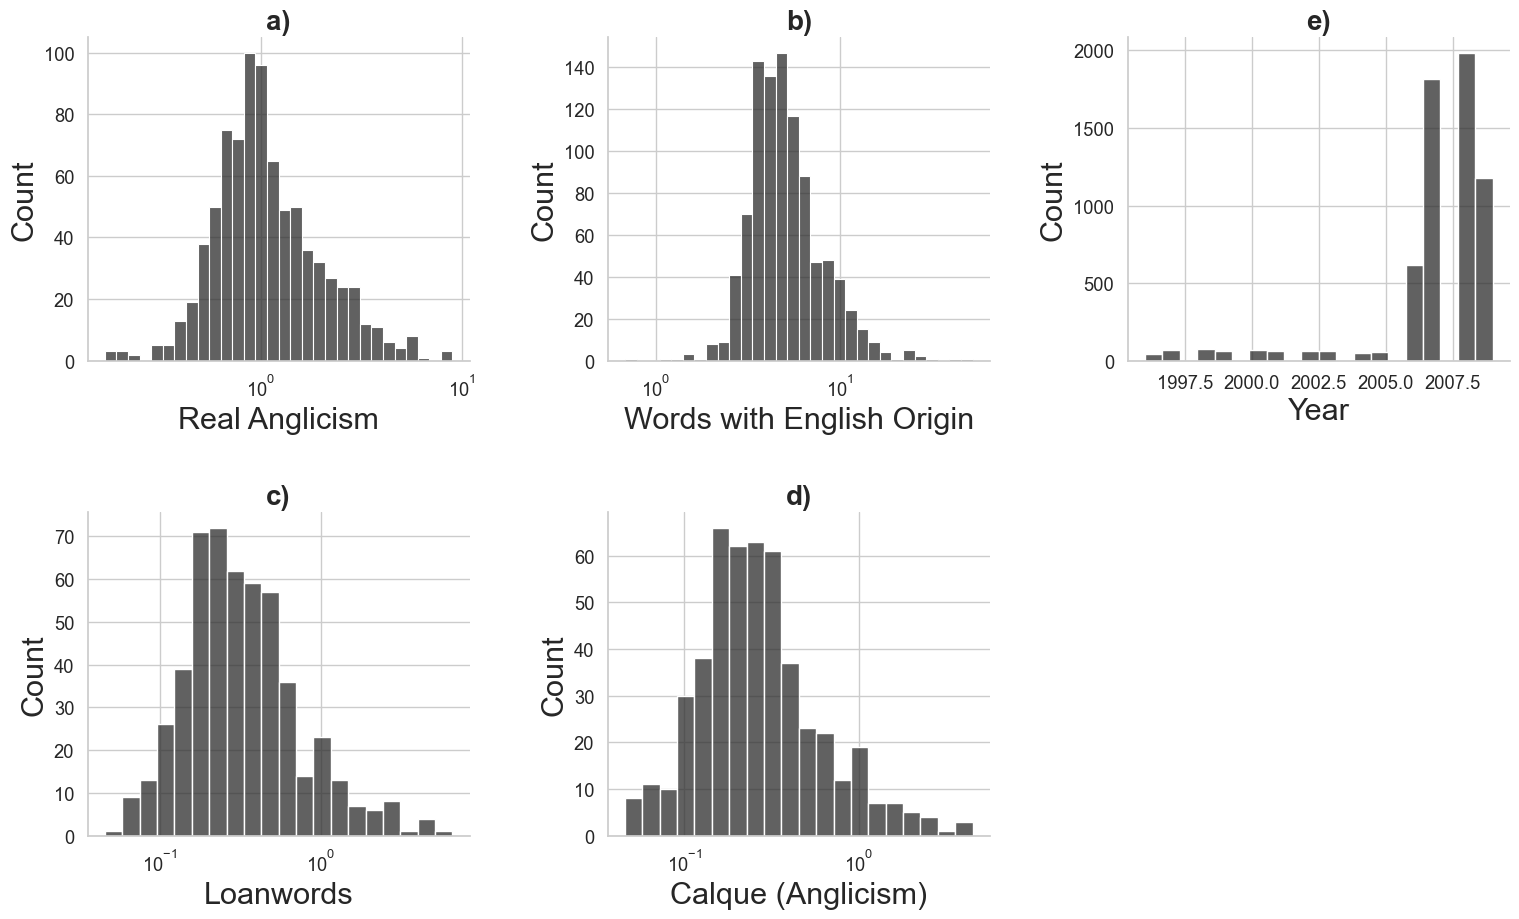

In [342]:
sns.set_theme(style="whitegrid", font_scale=1.2)
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
color = "#2C2C2C"

# --- a) Real anglicisms ---
sns.histplot(data=dataset_parlament_french, x='real_anglicism_rate',
             color=color, edgecolor="white", bins=30, ax=axes[0, 0], log_scale=True)
axes[0, 0].set_title("a)", fontsize=20, fontweight='bold')
axes[0, 0].set_xlabel("Real Anglicism", fontsize=22)
axes[0, 0].set_ylabel("Count", fontsize=22)
axes[0, 0].spines[['top', 'right']].set_visible(False)

# --- b) Words with English Origin ---
sns.histplot(data=dataset_parlament_french, x='english_origin_rate',
             color=color, edgecolor="white", bins=30, ax=axes[0, 1], log_scale=True)
axes[0, 1].set_title("b)", fontsize=20, fontweight='bold')
axes[0, 1].set_xlabel("Words with English Origin", fontsize=22)
axes[0, 1].set_ylabel("Count", fontsize=22)
axes[0, 1].spines[['top', 'right']].set_visible(False)

# --- c) Loanwords ---
sns.histplot(data=dataset_parlament_french, x='loanword_rate',
             color=color, edgecolor="white", bins=20, ax=axes[1, 0], log_scale=True)
axes[1, 0].set_title("c)", fontsize=20, fontweight='bold')
axes[1, 0].set_xlabel("Loanwords", fontsize=22)
axes[1, 0].set_ylabel("Count", fontsize=22)
axes[1, 0].spines[['top', 'right']].set_visible(False)

# --- d) Calque (Anglicism) ---
sns.histplot(data=dataset_parlament_french, x='complete_anglicism_rate',
             color=color, edgecolor="white", bins=20, ax=axes[1, 1], log_scale=True)
axes[1, 1].set_title("d)", fontsize=20, fontweight='bold')
axes[1, 1].set_xlabel("Calque (Anglicism)", fontsize=22)
axes[1, 1].set_ylabel("Count", fontsize=22)
axes[1, 1].spines[['top', 'right']].set_visible(False)

# --- e) Year ---
sns.histplot(data=dataset_parlament_french, x='year',
             color=color, edgecolor="white", bins=20, ax=axes[0, 2])
axes[0, 2].set_title("e)", fontsize=20, fontweight='bold')
axes[0, 2].set_xlabel("Year", fontsize=22)
axes[0, 2].set_ylabel("Count", fontsize=22)
axes[0, 2].spines[['top', 'right']].set_visible(False)

axes[1, 2].set_visible(False)
plt.tight_layout(pad=2.5)
plt.savefig("distributions_parlament_french.png", dpi=150, bbox_inches='tight')
plt.show()

**Figure** 1 - Monovariate description : a) Logarithmic distribution of real anglicism according to the Wiktionnaire b)Logarithmic distribution of words which have an english origin c) Logarithmic distribution of loanwords d) Logarithmic distribution of calque (anglicism) e) Distribution of speeches per year

### 5.2 Visualisations

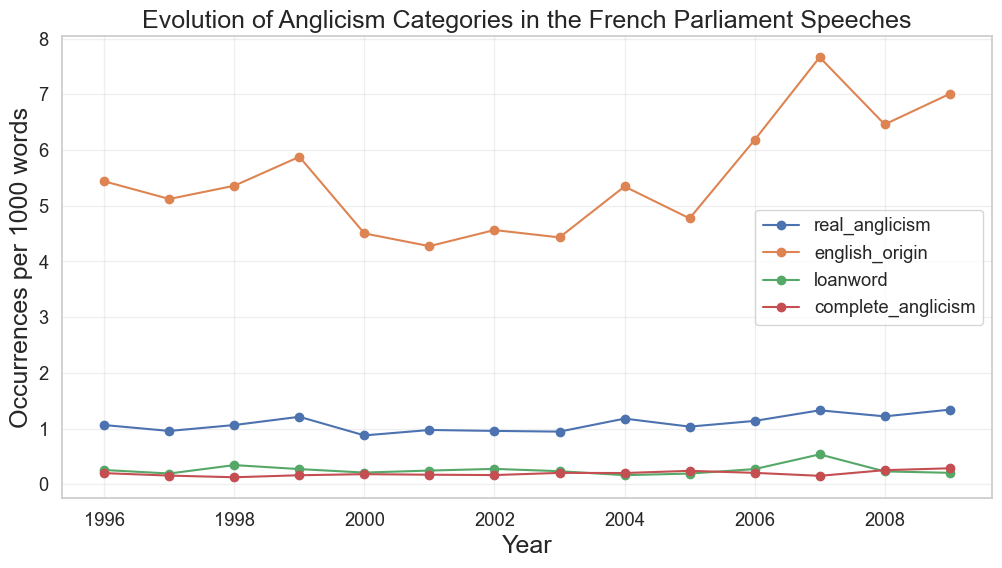

In [337]:
plt.figure(figsize=(12,6))

for col in [
    "real_anglicism_rate",
    "english_origin_rate",
    "loanword_rate",
    "complete_anglicism_rate"
]:
    plt.plot(
        yearly["year"],
        yearly[col],
        marker="o",
        label=col.replace("_rate","")
    )

plt.xlabel("Year", fontsize=18)
plt.ylabel("Occurrences per 1000 words", fontsize=18)
plt.title("Evolution of Anglicism Categories in the French Parliament Speeches", fontsize=18)
plt.legend()
plt.grid(alpha=.3)

plt.show()

**Figure 2** - Evolution of the rate of 4 anglicism's categories in the French Parliament speeches over time (1996-2009)

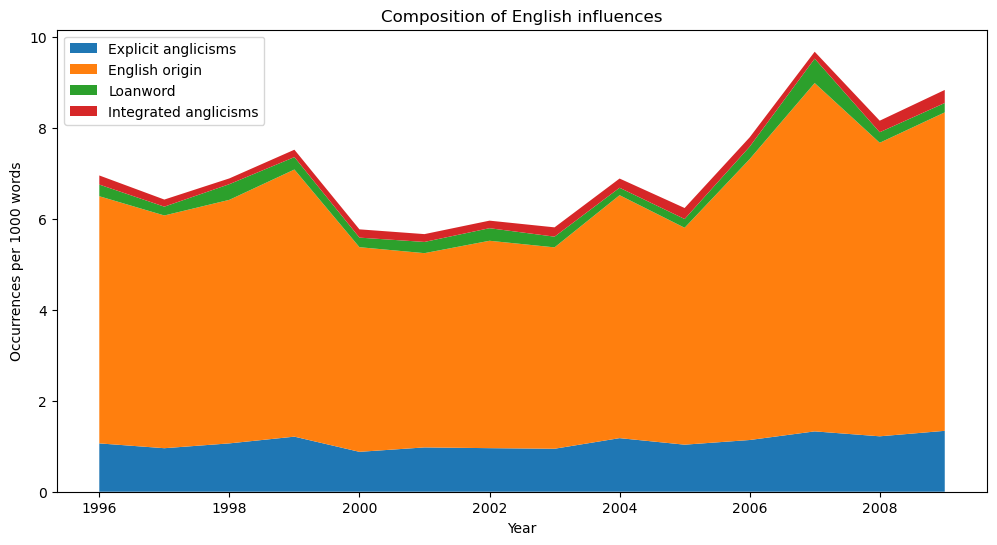

In [ ]:
plt.figure(figsize=(12,6))

plt.stackplot(
    yearly["year"],
    yearly["real_anglicism_rate"],
    yearly["english_origin_rate"],
    yearly["loanword_rate"],
    yearly["complete_anglicism_rate"],
    labels=[
        "Explicit anglicisms",
        "English origin",
        "Loanword",
        "Integrated anglicisms"
    ]
)

plt.legend(loc="upper left")
plt.xlabel("Year", fontsize=18)
plt.ylabel("Occurrences per 1000 words", fontsize=18)
plt.title("Composition of English influences", fontsize=18)

plt.show()

**Figure 3** - Composition of english influence with 4 anglicism's categories in the French Parliament speeches over time (1996-2009)

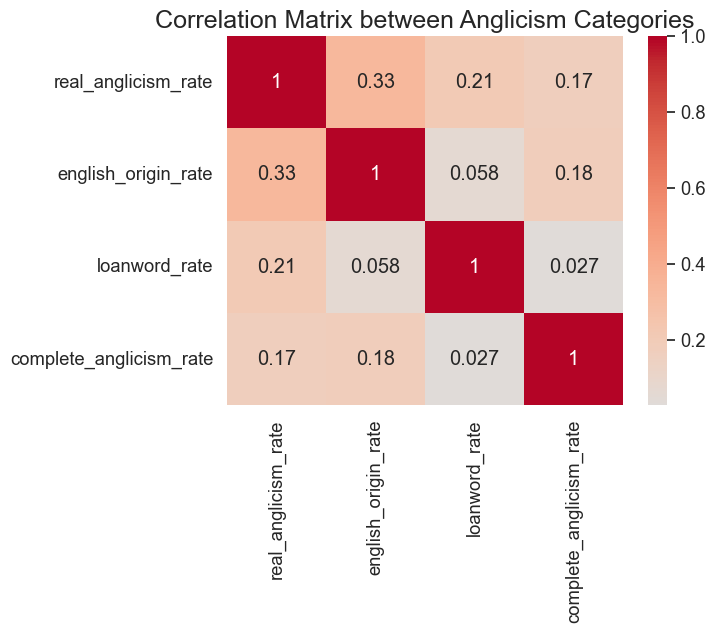

In [343]:
corr = dataset_parlament_french[["real_anglicism_rate", "english_origin_rate", "loanword_rate", "complete_anglicism_rate"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Matrix between Anglicism Categories", fontsize=18)
plt.show()

**Figure 4** - Correlation matrix between 4 anglicism's categories in the French Parliament speeches 

### 5.3 Statistical tests

#### 5.3.1 Linear regressions 

To test predictions 1, 2, 3 and 4, I performed 4 linear regressions on the real anglicism rate (Figure 1.a),  with years (Figure 1.e) (respectivelly on the words with english origins (Figure 1.b), loanwords (Figure 1.c) and complete/integrated anglicism (Figure 1.d) with years). 

I computed the following regression models:

$Anglicism_rate_{i} = β_{0} + β_{1} Year_{i} + \epsilon_{i}$

$English_origin_rate_{i} = β_{0} + β_{2} Year_{i} + \epsilon_{i}$

$Loanword_rate_{i} = β_{0} + β_{3} Year_{i} + \epsilon_{i}$

$Complete_anglicism_rate_{i} = β_{0} + β_{4} Year_{i} + \epsilon_{i}$

In [316]:
model_robust_real_anglicism = smf.ols(formula = 'year ~ real_anglicism_rate', data = dataset_parlament_french).fit(cov_type='HC3') 
print(model_robust_real_anglicism.summary())

                            OLS Regression Results                            
Dep. Variable:                   year   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                  0.009
Method:                 Least Squares   F-statistic:                     9.900
Date:                Sun, 31 May 2026   Prob (F-statistic):            0.00170
Time:                        15:10:04   Log-Likelihood:                -2782.5
No. Observations:                 976   AIC:                             5569.
Df Residuals:                     974   BIC:                             5579.
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept            2002.7692    

In [317]:
model_robust_english_origin_rate = smf.ols(formula = 'year ~ english_origin_rate', data = dataset_parlament_french).fit(cov_type='HC3') 
print(model_robust_english_origin_rate.summary())

                            OLS Regression Results                            
Dep. Variable:                   year   R-squared:                       0.032
Model:                            OLS   Adj. R-squared:                  0.031
Method:                 Least Squares   F-statistic:                     22.17
Date:                Sun, 31 May 2026   Prob (F-statistic):           2.85e-06
Time:                        15:10:16   Log-Likelihood:                -2771.3
No. Observations:                 976   AIC:                             5547.
Df Residuals:                     974   BIC:                             5556.
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept            2002.0814    

In [318]:
model_robust_loanword_rate = smf.ols(formula = 'year ~ loanword_rate', data = dataset_parlament_french).fit(cov_type='HC3') 
print(model_robust_loanword_rate.summary())

                            OLS Regression Results                            
Dep. Variable:                   year   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.2167
Date:                Sun, 31 May 2026   Prob (F-statistic):              0.642
Time:                        15:10:25   Log-Likelihood:                -2787.1
No. Observations:                 976   AIC:                             5578.
Df Residuals:                     974   BIC:                             5588.
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept      2003.1781      0.151   1.33e+04

In [319]:
model_robust_complete_anglicism = smf.ols(formula = 'year ~ complete_anglicism_rate', data = dataset_parlament_french).fit(cov_type='HC3') 
print(model_robust_complete_anglicism.summary())

                            OLS Regression Results                            
Dep. Variable:                   year   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     9.897
Date:                Sun, 31 May 2026   Prob (F-statistic):            0.00171
Time:                        15:10:35   Log-Likelihood:                -2783.9
No. Observations:                 976   AIC:                             5572.
Df Residuals:                     974   BIC:                             5581.
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                2

#### 5.3.2  Plot to visualize regressions 

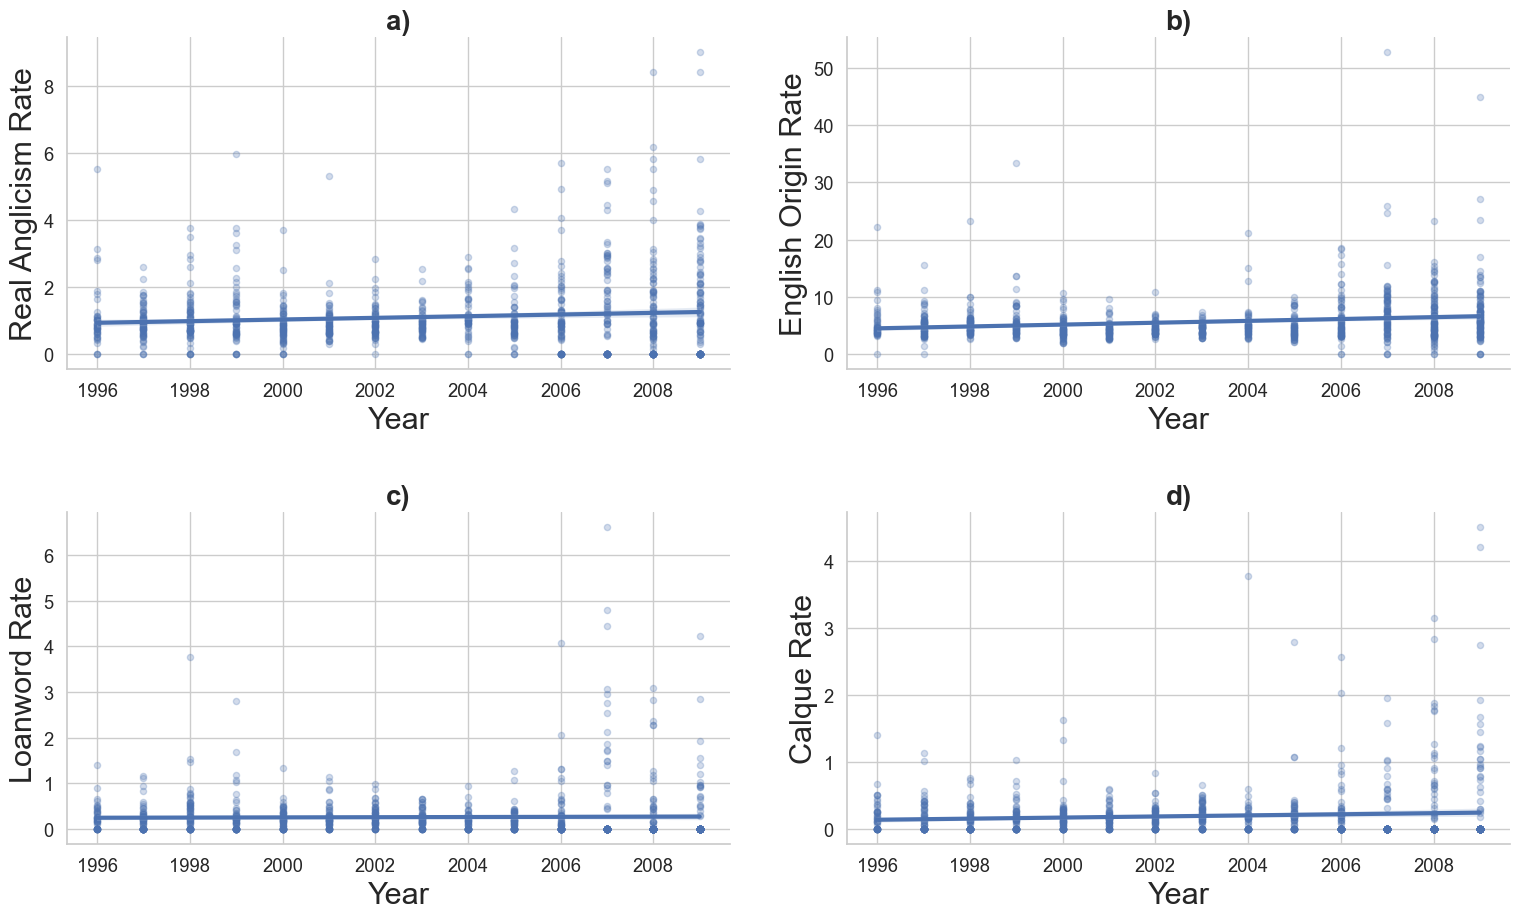

In [336]:
sns.set_theme(style="whitegrid", font_scale=1.2)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
color = "#2C2C2C"

# --- a) Real anglicisms ---
sns.regplot(data=dataset_parlament_french, x="year", y="real_anglicism_rate",
            scatter_kws={"alpha": 0.25, "s": 20}, line_kws={"linewidth": 3},
            ax=axes[0, 0])
axes[0, 0].set_title("a)", fontsize=20, fontweight='bold')
axes[0, 0].set_xlabel("Year", fontsize=22)
axes[0, 0].set_ylabel("Real Anglicism Rate", fontsize=22)
axes[0, 0].spines[['top', 'right']].set_visible(False)

# --- b) Words with English Origin ---
sns.regplot(data=dataset_parlament_french, x="year", y="english_origin_rate",
            scatter_kws={"alpha": 0.25, "s": 20}, line_kws={"linewidth": 3},
            ax=axes[0, 1])
axes[0, 1].set_title("b)", fontsize=20, fontweight='bold')
axes[0, 1].set_xlabel("Year", fontsize=22)
axes[0, 1].set_ylabel("English Origin Rate", fontsize=22)
axes[0, 1].spines[['top', 'right']].set_visible(False)

# --- c) Loanwords ---
sns.regplot(data=dataset_parlament_french, x="year", y="loanword_rate",
            scatter_kws={"alpha": 0.25, "s": 20}, line_kws={"linewidth": 3},
            ax=axes[1, 0])
axes[1, 0].set_title("c)", fontsize=20, fontweight='bold')
axes[1, 0].set_xlabel("Year", fontsize=22)
axes[1, 0].set_ylabel("Loanword Rate", fontsize=22)
axes[1, 0].spines[['top', 'right']].set_visible(False)

# --- d) Calque (Anglicism) ---
sns.regplot(data=dataset_parlament_french, x="year", y="complete_anglicism_rate",
            scatter_kws={"alpha": 0.25, "s": 20}, line_kws={"linewidth": 3},
            ax=axes[1, 1])
axes[1, 1].set_title("d)", fontsize=20, fontweight='bold')
axes[1, 1].set_xlabel("Year", fontsize=22)
axes[1, 1].set_ylabel("Calque Rate", fontsize=22)
axes[1, 1].spines[['top', 'right']].set_visible(False)

plt.tight_layout(pad=2.5)
plt.savefig("distributions_parlament_french.png", dpi=150, bbox_inches='tight')
plt.show()

**Figure 5** - Visual results of the 4 linear regressions with regression plot

## 6. Conclusion 

My study revealed that real anglicisms (according to the Wiktionnaire) and complete/integrated anglicisms in french are significantly and positively correlated with years  (β 1 =  0.394, p < 0.01, R² = 0.010, see Table 1) (β 4 = 0.849 , p < 0.01 , R² = 0.007, see Table 2). Whereas loanwords show no significant correlation with years(β 3 =  0.117, p = 0.642, R² = 0, see Table 2).

Words with english origin are also significantly and positively correlated with years (β 2 =  0.198, p < 0.01, R² = 0.032, see Table 2), which indicates that not only anglicisms but the language itself reveals a transformation in our use.
Which means the number of anglicism used in the parliament by french speakers tends to grow with the years, which at first wasn't sure taking the political context into account.  

A possible extension of my study could involve including Anglicisms in the form of hybrid words, as well as conducting a cross-linguistic study involving other languages spoken in Parliament; in that case, I would need to find a sufficiently comprehensive dictionary for each language. In this context, I believe that conducting similarity tests between the correlation matrices of the various categories of Anglicisms would be a sound method.

# 7. References 

[1] Humbley, J. (2010). Peut-on encore parler d'anglicisme?. In Lexique, normalisation, transgression (pp. 21-45). Mes Mots Edition. Limay.

[2] Humbley, J. (2023). Traitement lexicographique des anglicismes phraséologiques. Linx. Revue des linguistes de l’université Paris X Nanterre, (86).
